In [1]:
import tensorflow as tf
import numpy as np
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.utils import to_categorical
import cv2
import matplotlib.pyplot as plt

In [2]:
# Load LFW dataset with minimum 20 images per person
lfw_people = fetch_lfw_people(min_faces_per_person=20, resize=0.5)
images = lfw_people.images
labels = lfw_people.target
label_names = lfw_people.target_names
num_classes = len(label_names)

print("Total samples:", images.shape[0])
print("Image shape:", images.shape[1:])
print("Number of classes:", num_classes)

Total samples: 3023
Image shape: (62, 47)
Number of classes: 62


In [3]:
# Resize images to 224x224 RGB for VGG16
resized_images = np.zeros((images.shape[0], 224, 224, 3), dtype='float32')

for i in range(images.shape[0]):
    img = cv2.cvtColor(images[i], cv2.COLOR_GRAY2RGB)
    resized_images[i] = cv2.resize(img, (224, 224))

In [4]:
 # Normalize with VGG16 preprocessing
resized_images = preprocess_input(resized_images)

In [5]:
 # Load pre-trained VGG16 (excluding top layer)
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))



58889256/58889256 [==============================] - 10s 0us/step


In [8]:
# Extract features from images
features = vgg_model.predict(resized_images, verbose=1)
features = features.reshape(features.shape[0], -1)  # Flatten features

95/95 [==============================] - 604s 6s/step


In [9]:
 # One-hot encode labels
labels_cat = to_categorical(labels, num_classes)

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, labels_cat, test_size=0.2, random_state=42)
model = tf.keras.models.Sequential([
tf.keras.layers.Dense(512, activation='relu', input_shape=(features.shape[1],)),
tf.keras.layers.Dropout(0.5),
tf.keras.layers.Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               12845568  
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 62)                31806     
                                                                 
Total params: 12877374 (49.12 MB)
Trainable params: 12877374 (49.12 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [11]:
history = model.fit(
X_train, y_train,
epochs=10,
batch_size=32,
validation_split=0.2
)

Epoch 1/10


61/61 [==============================] - 13s 150ms/step - loss: 4.5741 - accuracy: 0.1034 - val_loss: 3.8601 - val_accuracy: 0.1880
Epoch 2/10
61/61 [==============================] - 9s 141ms/step - loss: 3.8796 - accuracy: 0.1680 - val_loss: 3.7931 - val_accuracy: 0.1880
Epoch 3/10
61/61 [==============================] - 8s 125ms/step - loss: 3.8361 - accuracy: 0.1768 - val_loss: 3.7708 - val_accuracy: 0.1880
Epoch 4/10
61/61 [==============================] - 8s 126ms/step - loss: 3.8175 - accuracy: 0.1768 - val_loss: 3.7151 - val_accuracy: 0.1880
Epoch 5/10
61/61 [==============================] - 8s 123ms/step - loss: 3.8289 - accuracy: 0.1768 - val_loss: 3.7701 - val_accuracy: 0.1880
Epoch 6/10
61/61 [==============================] - 8s 132ms/step - loss: 3.8565 - accuracy: 0.1768 - val_loss: 3.7769 - val_accuracy: 0.1880
Epoch 7/10
61/61 [==============================] - 8s 126ms/step - loss: 3.8369 - accuracy: 0.1768 - val_loss: 3.7474 - val_accuracy: 0.1880
Epo

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print("✅Test Accuracy:", accuracy)

19/19 [==============================] - 0s 8ms/step - loss: 3.7268 - accuracy: 0.1603
✅Test Accuracy: 0.16033057868480682


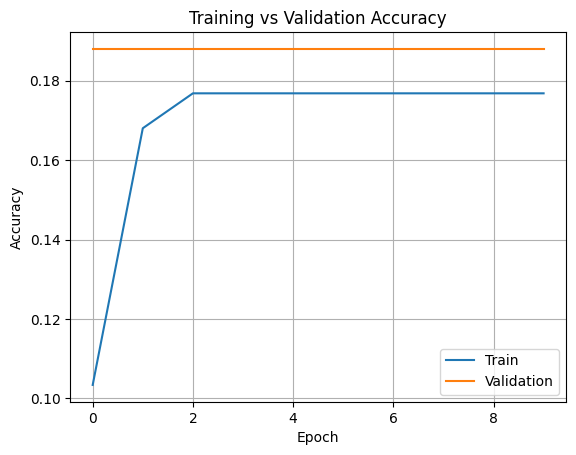

In [13]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()